Downloading the datadet

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yogeshwaran005/plant-disease-detection")

print("Path to dataset files:", path)

100%|██████████| 5.05G/5.05G [01:13<00:00, 74.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yogeshwaran005/plant-disease-detection/versions/1


note: I merged the dataset with another dataset of kaggle. The final dataset is the combination of the two datasets in the links below:

1- https://www.kaggle.com/datasets/yogeshwaran005/plants-disease-detection

2- https://www.kaggle.com/datasets/emmarex/plantdisease

Connecting to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir("/content/drive/My Drive/plant-disease-detection/Plant Disease Detection")

['Corn', 'Tomato', 'Rice', 'Wheat']

In [ ]:
import os

# مسیر فولدر اصلی دیتاست را مشخص کنید
base_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection"

# پیمایش فولدرها و شمارش تصاویر در هر پوشه
def count_images_in_folders(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for plant in sorted(os.listdir(base_path)):
        plant_path = os.path.join(base_path, plant)
        if os.path.isdir(plant_path):
            print(f"\nPlant: {plant}")
            for disease in sorted(os.listdir(plant_path)):
                disease_path = os.path.join(plant_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
count_images_in_folders(base_path)


Plant: Corn
  common_rust: 540 images
  grey_leaf_spot: 513 images
  healthy: 561 images
  northern_leaf_blight: 567 images

Plant: Rice
  Rice___Brown_Spot: 613 images
  Rice___Leaf_Blast: 610 images
  Rice___Neck_Blast: 611 images
  Rice_healthy: 600 images

Plant: Tomato
  Tomato_Bacterial_spot: 1012 images
  Tomato_Early_blight: 1000 images
  Tomato_Late_blight: 1000 images
  Tomato_Leaf_Mold: 952 images
  Tomato_Septoria_leaf_spot: 1000 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 1000 images
  Tomato__Target_Spot: 1000 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 999 images
  Tomato_healthy: 1000 images

Plant: Wheat
  Wheat___Brown_Rust: 902 images
  Wheat___Yellow_Rust: 924 images
  Wheat_healthy: 912 images


In [ ]:
import os

def display_folder_structure_with_counts(base_path, indent=0):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    # بررسی محتوای فولدر
    for item in sorted(os.listdir(base_path)):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            print(" " * indent + f"📁 {item}/")
            display_folder_structure_with_counts(item_path, indent + 4)
        else:
            if item.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue
            print(" " * indent + f"📄 {item}")

    # شمارش تصاویر
    image_count = len([file for file in os.listdir(base_path)
                       if os.path.isfile(os.path.join(base_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
    if image_count > 0:
        print(" " * indent + f"📸 {image_count} images")

# مسیر فولدر اصلی دیتاست را مشخص کنید
base_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection"

# اجرا
display_folder_structure_with_counts(base_path)

📁 Corn/
    📁 common_rust/
        📸 540 images
    📁 grey_leaf_spot/
        📸 513 images
    📁 healthy/
        📸 561 images
    📁 northern_leaf_blight/
        📸 567 images
📁 Rice/
    📁 Rice___Brown_Spot/
        📸 613 images
    📁 Rice___Leaf_Blast/
        📸 610 images
    📁 Rice___Neck_Blast/
        📸 611 images
    📁 Rice_healthy/
        📸 600 images
📁 Tomato/
    📁 Tomato_Bacterial_spot/
        📸 1012 images
    📁 Tomato_Early_blight/
        📸 1000 images
    📁 Tomato_Late_blight/
        📸 1000 images
    📁 Tomato_Leaf_Mold/
        📸 952 images
    📁 Tomato_Septoria_leaf_spot/
        📸 1000 images
    📁 Tomato_Spider_mites_Two_spotted_spider_mite/
        📸 1000 images
    📁 Tomato__Target_Spot/
        📸 1000 images
    📁 Tomato__Tomato_YellowLeaf__Curl_Virus/
        📸 999 images
    📁 Tomato_healthy/
        📸 1000 images
📁 Wheat/
    📁 Wheat___Brown_Rust/
        📸 902 images
    📁 Wheat___Yellow_Rust/
        📸 924 images
    📁 Wheat_healthy/
        📸 912 images


preprocess

In [ ]:
import os
import shutil
import random

# نسبت‌های تقسیم‌بندی
test_ratio = 0.15
val_ratio = 0.15

# تابع تقسیم داده‌ها
def split_data_for_plant(plant_path, output_base_path):
    if not os.path.exists(plant_path):
        print("Invalid plant path. Please check the folder path.")
        return

    plant_name = os.path.basename(plant_path)
    output_path = os.path.join(output_base_path, plant_name)
    train_path = os.path.join(output_path, "Train")
    val_path = os.path.join(output_path, "Validation")
    test_path = os.path.join(output_path, "Test")

    for folder in [train_path, val_path, test_path]:
        os.makedirs(folder, exist_ok=True)

    print(f"Processing plant: {plant_name}")
    for disease in sorted(os.listdir(plant_path)):
        disease_path = os.path.join(plant_path, disease)
        if os.path.isdir(disease_path):
            files = [f for f in os.listdir(disease_path)
                     if os.path.isfile(os.path.join(disease_path, f)) and f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            random.shuffle(files)
            total_files = len(files)

            test_count = int(total_files * test_ratio)
            val_count = int(total_files * val_ratio)

            test_files = files[:test_count]
            val_files = files[test_count:test_count + val_count]
            train_files = files[test_count + val_count:]

            for file_set, target_path in zip([train_files, val_files, test_files], [train_path, val_path, test_path]):
                disease_output_path = os.path.join(target_path, disease)
                os.makedirs(disease_output_path, exist_ok=True)
                for file in file_set:
                    shutil.copy(os.path.join(disease_path, file), os.path.join(disease_output_path, file))

            print(f"  {disease}: Train={len(train_files)}, Validation={len(val_files)}, Test={len(test_files)}")

اجرا برای گیاه corn

In [ ]:
# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Corn"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Processing plant: Corn
  common_rust: Train=378, Validation=81, Test=81
  grey_leaf_spot: Train=361, Validation=76, Test=76
  healthy: Train=393, Validation=84, Test=84
  northern_leaf_blight: Train=397, Validation=85, Test=85


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Corn را مشخص کنید
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Corn"

# پیمایش فولدرهای Train، Validation و Test و شمارش تصاویر
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  common_rust: 378 images
  grey_leaf_spot: 361 images
  healthy: 393 images
  northern_leaf_blight: 397 images

Validation folder contents:
  common_rust: 81 images
  grey_leaf_spot: 76 images
  healthy: 84 images
  northern_leaf_blight: 85 images

Test folder contents:
  common_rust: 81 images
  grey_leaf_spot: 76 images
  healthy: 84 images
  northern_leaf_blight: 85 images


data augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation برای داده‌های آموزش
train_datagen = ImageDataGenerator(
    rescale=1./255,  # نرمال‌سازی پیکسل‌ها
    rotation_range=40,  # چرخش تصاویر
    width_shift_range=0.2,  # تغییر موقعیت عرضی
    height_shift_range=0.2,  # تغییر موقعیت عمودی
    shear_range=0.2,  # چرخش تصاویر
    zoom_range=0.2,  # بزرگ‌نمایی
    horizontal_flip=True,  # برعکس کردن تصاویر
    fill_mode='nearest'  # پر کردن پیکسل‌های خالی
)

# برای داده‌های اعتبارسنجی و تست فقط نرمال‌سازی انجام می‌دهیم
test_datagen = ImageDataGenerator(rescale=1./255)

# بارگذاری داده‌ها
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Corn/Train',
    target_size=(224, 224),  # تغییر اندازه تصاویر
    batch_size=32,
    class_mode='categorical'  # از برچسب‌های دسته‌بندی استفاده می‌کنیم
)

validation_generator = test_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Corn/Validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Corn/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1529 images belonging to 4 classes.
Found 326 images belonging to 4 classes.
Found 326 images belonging to 4 classes.


model building

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# بارگذاری مدل VGG16 از پیش آموزش‌دیده بدون لایه‌های خروجی
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# لایه‌های جدید مدل
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())  # صاف کردن ویژگی‌ها
model.add(layers.Dense(512, activation='relu'))  # لایه Fully Connected
model.add(layers.Dense(4, activation='softmax'))  # تعداد دسته‌ها را مطابق با بیماری‌های گیاهی (در اینجا 4) تنظیم کنید

# تنظیمات مدل
base_model.trainable = False  # برای جلوگیری از آموزش مجدد لایه‌های پیش‌آموزش دیده

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# نمایش ساختار مدل
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,562,308 (105.14 MB)

 Trainable params: 12,847,620 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

model training

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 1065s 23s/step - accuracy: 0.5223 - loss: 3.7982 - val_accuracy: 0.8625 - val_loss: 0.3301
Epoch 2/10
 1/47 ━━━━━━━━━━━━━━━━━━━━ 13:27 18s/step - accuracy: 0.9062 - loss: 0.2732

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.9062 - loss: 0.2732 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1068s 22s/step - accuracy: 0.8681 - loss: 0.4016 - val_accuracy: 0.9312 - val_loss: 0.2982
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.6875 - loss: 0.8572 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1050s 22s/step - accuracy: 0.8640 - loss: 0.4080 - val_accuracy: 0.9094 - val_loss: 0.2704
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.9062 - loss: 0.2319 - val_accuracy: 1.0000 - val_loss: 0.1352
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1050s 22s/step - accuracy: 0.9117 - loss: 0.2761 - val_accuracy: 0.9156 - val_loss: 0.2152
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9062 - loss: 0.2502 - val_accuracy: 0.8333 - val_loss: 0.5661
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1085s 22s/step - accuracy: 0.9260 - loss: 0.2243 - val_accuracy: 0.9406 -

ارزیابی مدل

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test accuracy: {test_acc * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 184s 18s/step - accuracy: 0.9383 - loss: 0.1520
Test accuracy: 94.06%


In [ ]:
# نام مخصوص گیاه Corn
model_name = 'corn_plant_disease_model.h5'

# ذخیره مدل با نام مخصوص گیاه
model.save(model_name)

In [ ]:
# مسیر دلخواه برای ذخیره مدل
model_save_path = '/content/drive/My Drive/models/corn_plant_disease_model.h5'

# ذخیره مدل
model.save(model_save_path)

print(f"Model saved at: {model_save_path}")

Model saved at: /content/drive/My Drive/models/corn_plant_disease_model.h5


In [ ]:
import os

# مشخص کردن فولدر برای جستجو
model_folder = "/content/drive/My Drive/models"

# لیست کردن فایل‌های داخل پوشه
model_files = [f for f in os.listdir(model_folder) if f.endswith('.h5')]

# نمایش فایل‌ها
print("Model files found:")
for file in model_files:
    print(f"- {file}")

Model files found:
- corn_plant_disease_model.h5


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/My Drive/models/corn_plant_disease_model.h5')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 326 images belonging to 4 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 182s 18s/step


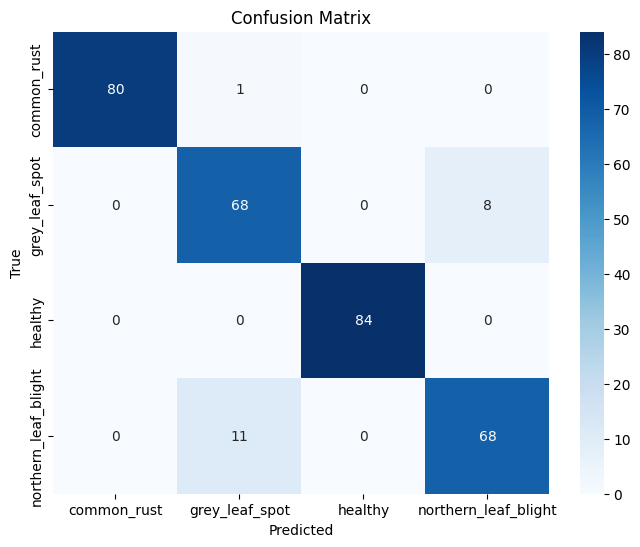

In [ ]:
# بارگذاری داده‌های تست
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Corn/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # مهم: ترتیب داده‌ها تغییر نکند
)

# پیش‌بینی نتایج برای داده‌های تست
y_pred = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size)
y_pred_classes = np.argmax(y_pred, axis=1)  # تبدیل خروجی به کلاس‌های پیش‌بینی شده

# برچسب‌های واقعی
y_true = test_generator.classes

# حذف پیش‌بینی‌های اضافی و برچسب‌های واقعی اضافی
y_true = y_true[:len(y_pred_classes)]
y_pred_classes = y_pred_classes[:len(y_true)]

# ایجاد ماتریس سردرگمی
cm = confusion_matrix(y_true, y_pred_classes)

# رسم ماتریس سردرگمی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

تست بگیریم :))

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# بارگذاری مدل ذخیره شده
model_path = '/content/drive/My Drive/models/corn_plant_disease_model.h5'
model = load_model(model_path)

In [ ]:
# آپلود تصویر
uploaded = files.upload()

# گرفتن نام فایل آپلود شده
img_path = next(iter(uploaded))

In [ ]:
mg = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
# بارگذاری و پیش‌پردازش تصویر
img_array = np.expand_dims(img_array, axis=0)  # تبدیل به آرایه با ابعاد (1, 224, 224, 3)
img_array /= 255.0  # نرمال‌سازی پیکسل‌ها

# پیش‌بینی بیماری گیاه
predictions = model.predict(img_array)

In [ ]:
# نمایش نتایج
class_names = ['common_rust', 'grey_leaf_spot', 'healthy', 'northern_leaf_blight']  # لیست دسته‌ها
predicted_class = class_names[np.argmax(predictions)]

# نمایش تصویر
plt.imshow(img)
plt.title(f"Predicted Disease: {predicted_class}")
plt.axis('off')
plt.show()

print(f"Predicted Disease: {predicted_class}")

برای گیاه Tomato

preprocess

In [ ]:
# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Tomato"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Processing plant: Tomato
  Tomato_Bacterial_spot: Train=710, Validation=151, Test=151
  Tomato_Early_blight: Train=700, Validation=150, Test=150
  Tomato_Late_blight: Train=700, Validation=150, Test=150
  Tomato_Leaf_Mold: Train=668, Validation=142, Test=142
  Tomato_Septoria_leaf_spot: Train=700, Validation=150, Test=150
  Tomato_Spider_mites_Two_spotted_spider_mite: Train=700, Validation=150, Test=150


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Corn را مشخص کنید
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Tomato"

# پیمایش فولدرهای Train، Validation و Test و شمارش تصاویر
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  Tomato_Bacterial_spot: 1004 images
  Tomato_Early_blight: 988 images
  Tomato_Late_blight: 991 images
  Tomato_Leaf_Mold: 946 images
  Tomato_Septoria_leaf_spot: 991 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 990 images
  Tomato__Target_Spot: 992 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 984 images
  Tomato_healthy: 999 images

Validation folder contents:
  Tomato_Bacterial_spot: 491 images
  Tomato_Early_blight: 485 images
  Tomato_Late_blight: 469 images
  Tomato_Leaf_Mold: 442 images
  Tomato_Septoria_leaf_spot: 461 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 463 images
  Tomato__Target_Spot: 496 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 481 images
  Tomato_healthy: 478 images

Test folder contents:
  Tomato_Bacterial_spot: 480 images
  Tomato_Early_blight: 475 images
  Tomato_Late_blight: 488 images
  Tomato_Leaf_Mold: 448 images
  Tomato_Septoria_leaf_spot: 473 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 463 imag

In [ ]:
import os
import shutil

# تابع برای حذف فولدرها و داده‌های داخل آنها
def remove_folders(base_path):
    for folder in ['Train', 'Validation', 'Test']:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)  # حذف فولدر و محتوای داخل آن
            print(f"Deleted {folder} folder.")

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Tomato
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Tomato"

# حذف فولدرهای قبلی
remove_folders(base_path)

# اکنون می‌توانید کد تقسیم داده‌ها را دوباره اجرا کنید:
# نسبت‌های تقسیم‌بندی
test_ratio = 0.15
val_ratio = 0.15

# تابع تقسیم داده‌ها
def split_data_for_plant(plant_path, output_base_path):
    if not os.path.exists(plant_path):
        print("Invalid plant path. Please check the folder path.")
        return

    plant_name = os.path.basename(plant_path)
    output_path = os.path.join(output_base_path, plant_name)
    train_path = os.path.join(output_path, "Train")
    val_path = os.path.join(output_path, "Validation")
    test_path = os.path.join(output_path, "Test")

    for folder in [train_path, val_path, test_path]:
        os.makedirs(folder, exist_ok=True)

    print(f"Processing plant: {plant_name}")
    for disease in sorted(os.listdir(plant_path)):
        disease_path = os.path.join(plant_path, disease)
        if os.path.isdir(disease_path):
            files = [f for f in os.listdir(disease_path)
                     if os.path.isfile(os.path.join(disease_path, f)) and f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            random.shuffle(files)
            total_files = len(files)

            test_count = int(total_files * test_ratio)
            val_count = int(total_files * val_ratio)

            test_files = files[:test_count]
            val_files = files[test_count:test_count + val_count]
            train_files = files[test_count + val_count:]

            for file_set, target_path in zip([train_files, val_files, test_files], [train_path, val_path, test_path]):
                disease_output_path = os.path.join(target_path, disease)
                os.makedirs(disease_output_path, exist_ok=True)
                for file in file_set:
                    shutil.copy(os.path.join(disease_path, file), os.path.join(disease_output_path, file))

            print(f"  {disease}: Train={len(train_files)}, Validation={len(val_files)}, Test={len(test_files)}")

# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Tomato"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Deleted Train folder.
Deleted Validation folder.
Deleted Test folder.
Processing plant: Tomato
  Tomato_Bacterial_spot: Train=710, Validation=151, Test=151
  Tomato_Early_blight: Train=700, Validation=150, Test=150
  Tomato_Late_blight: Train=700, Validation=150, Test=150
  Tomato_Leaf_Mold: Train=668, Validation=142, Test=142
  Tomato_Septoria_leaf_spot: Train=700, Validation=150, Test=150
  Tomato_Spider_mites_Two_spotted_spider_mite: Train=700, Validation=150, Test=150
  Tomato__Target_Spot: Train=700, Validation=150, Test=150
  Tomato__Tomato_YellowLeaf__Curl_Virus: Train=701, Validation=149, Test=149
  Tomato_healthy: Train=700, Validation=150, Test=150


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Tomato
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Tomato"

# تابع برای شمارش تصاویر در هر دسته
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  Tomato_Bacterial_spot: 710 images
  Tomato_Early_blight: 700 images
  Tomato_Late_blight: 700 images
  Tomato_Leaf_Mold: 668 images
  Tomato_Septoria_leaf_spot: 700 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 700 images
  Tomato__Target_Spot: 700 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 701 images
  Tomato_healthy: 700 images

Validation folder contents:
  Tomato_Bacterial_spot: 151 images
  Tomato_Early_blight: 150 images
  Tomato_Late_blight: 150 images
  Tomato_Leaf_Mold: 142 images
  Tomato_Septoria_leaf_spot: 150 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 150 images
  Tomato__Target_Spot: 150 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 149 images
  Tomato_healthy: 150 images

Test folder contents:
  Tomato_Bacterial_spot: 151 images
  Tomato_Early_blight: 150 images
  Tomato_Late_blight: 150 images
  Tomato_Leaf_Mold: 142 images
  Tomato_Septoria_leaf_spot: 150 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 150 image

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# مسیر فولدرهای داده‌ها
train_dir = "/content/drive/My Drive/plant-disease-detection/Processed Data/Tomato/Train"
val_dir = "/content/drive/My Drive/plant-disease-detection/Processed Data/Tomato/Validation"
test_dir = "/content/drive/My Drive/plant-disease-detection/Processed Data/Tomato/Test"

In [ ]:
# ایجاد ImageDataGenerators برای داده‌های آموزشی، اعتبارسنجی و تست
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, width_shift_range=0.2,
                                   height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
                                   horizontal_flip=True, fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 6279 images belonging to 9 classes.
Found 1342 images belonging to 9 classes.
Found 1342 images belonging to 9 classes.


In [ ]:
# بارگذاری مدل MobileNetV2 از پیش آموزش‌دیده
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# لایه‌های جدید مدل
model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())  # کاهش ابعاد ویژگی‌ها
model.add(layers.Dense(512, activation='relu'))  # لایه Fully Connected
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))  # تعداد دسته‌ها مطابق با بیماری‌ها

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# تنظیمات مدل
base_model.trainable = False  # جلوگیری از آموزش لایه‌های پیش‌آموزش دیده

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# آموزش مدل
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


197/197 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.6555 - loss: 0.9636 - val_accuracy: 0.8525 - val_loss: 0.4170
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.8707 - loss: 0.3577 - val_accuracy: 0.8390 - val_loss: 0.4478
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.8868 - loss: 0.3007 - val_accuracy: 0.8294 - val_loss: 0.4743
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.9027 - loss: 0.2616 - val_accuracy: 0.8636 - val_loss: 0.3924
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.9121 - loss: 0.2489 - val_accuracy: 0.9083 - val_loss: 0.2617
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.9237 - loss: 0.2203 - val_accuracy: 0.8450 - val_loss: 0.4643
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.9179 - loss: 0.2208 - val_accuracy: 0.8584 - val_loss: 0.4097
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.9169 - loss: 0.2337 - val_accuracy: 0.857

In [ ]:
# ارزیابی مدل روی داده‌های تست
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9033 - loss: 0.2661
Test accuracy: 90.61%


In [ ]:
# ذخیره مدل به صورت HDF5
model.save("/content/drive/My Drive/models/Tomato_plant_disease_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

# مشخص کردن فولدر برای جستجو
model_folder = "/content/drive/My Drive/models"

# لیست کردن فایل‌های داخل پوشه
model_files = [f for f in os.listdir(model_folder) if f.endswith('.h5')]

# نمایش فایل‌ها
print("Model files found:")
for file in model_files:
    print(f"- {file}")

Model files found:
- corn_plant_disease_model.h5
- Tomato_plant_disease_model.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step


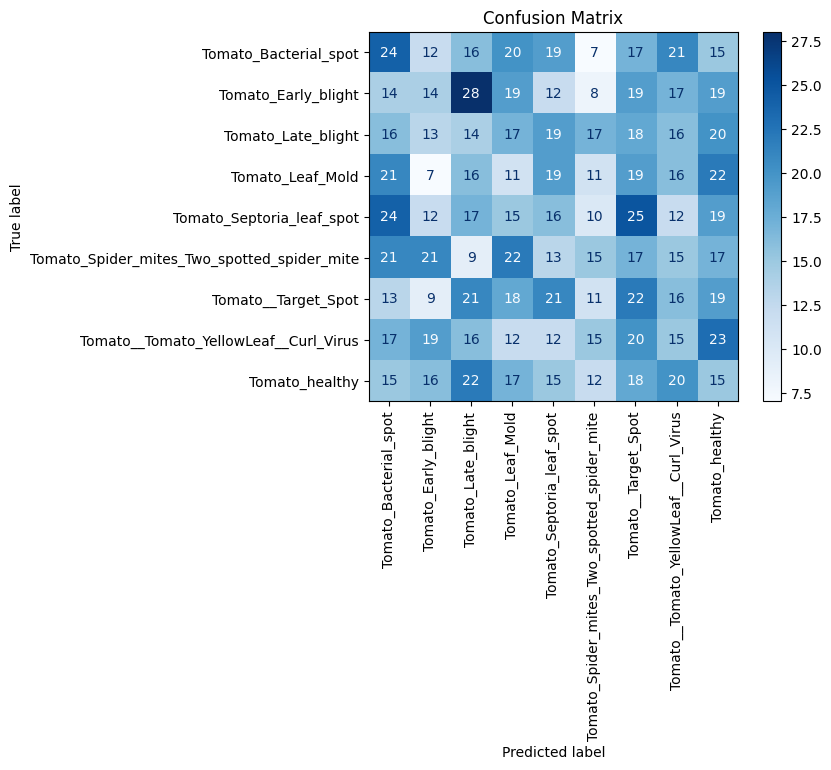

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# دریافت پیش‌بینی‌ها
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# دریافت کلاس‌های واقعی
y_true = test_generator.classes

# بررسی ابعاد y_true و y_pred_classes
if len(y_true) != len(y_pred_classes):
    print("Mismatch in y_true and y_pred_classes lengths!")
else:
    # ایجاد ماتریس سردرگمی
    cm = confusion_matrix(y_true, y_pred_classes)
    class_names = list(test_generator.class_indices.keys())  # نام کلاس‌ها

    # رسم ماتریس سردرگمی
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
    plt.title("Confusion Matrix")
    plt.show()

برای گیاه Rice

preprocessing

In [ ]:
# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Rice"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Processing plant: Rice
  Rice___Brown_Spot: Train=431, Validation=91, Test=91
  Rice___Leaf_Blast: Train=428, Validation=91, Test=91
  Rice___Neck_Blast: Train=429, Validation=91, Test=91
  Rice_healthy: Train=420, Validation=90, Test=90


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Corn را مشخص کنید
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Rice"

# پیمایش فولدرهای Train، Validation و Test و شمارش تصاویر
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  Rice___Brown_Spot: 606 images
  Rice___Leaf_Blast: 604 images
  Rice___Neck_Blast: 609 images
  Rice_healthy: 594 images

Validation folder contents:
  Rice___Brown_Spot: 279 images
  Rice___Leaf_Blast: 288 images
  Rice___Neck_Blast: 291 images
  Rice_healthy: 285 images

Test folder contents:
  Rice___Brown_Spot: 286 images
  Rice___Leaf_Blast: 285 images
  Rice___Neck_Blast: 295 images
  Rice_healthy: 282 images


In [ ]:
import os
import shutil

# تابع برای حذف فولدرها و داده‌های داخل آنها
def remove_folders(base_path):
    for folder in ['Train', 'Validation', 'Test']:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)  # حذف فولدر و محتوای داخل آن
            print(f"Deleted {folder} folder.")

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Tomato
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Rice"

# حذف فولدرهای قبلی
remove_folders(base_path)

# اکنون می‌توانید کد تقسیم داده‌ها را دوباره اجرا کنید:
# نسبت‌های تقسیم‌بندی
test_ratio = 0.15
val_ratio = 0.15

# تابع تقسیم داده‌ها
def split_data_for_plant(plant_path, output_base_path):
    if not os.path.exists(plant_path):
        print("Invalid plant path. Please check the folder path.")
        return

    plant_name = os.path.basename(plant_path)
    output_path = os.path.join(output_base_path, plant_name)
    train_path = os.path.join(output_path, "Train")
    val_path = os.path.join(output_path, "Validation")
    test_path = os.path.join(output_path, "Test")

    for folder in [train_path, val_path, test_path]:
        os.makedirs(folder, exist_ok=True)

    print(f"Processing plant: {plant_name}")
    for disease in sorted(os.listdir(plant_path)):
        disease_path = os.path.join(plant_path, disease)
        if os.path.isdir(disease_path):
            files = [f for f in os.listdir(disease_path)
                     if os.path.isfile(os.path.join(disease_path, f)) and f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            random.shuffle(files)
            total_files = len(files)

            test_count = int(total_files * test_ratio)
            val_count = int(total_files * val_ratio)

            test_files = files[:test_count]
            val_files = files[test_count:test_count + val_count]
            train_files = files[test_count + val_count:]

            for file_set, target_path in zip([train_files, val_files, test_files], [train_path, val_path, test_path]):
                disease_output_path = os.path.join(target_path, disease)
                os.makedirs(disease_output_path, exist_ok=True)
                for file in file_set:
                    shutil.copy(os.path.join(disease_path, file), os.path.join(disease_output_path, file))

            print(f"  {disease}: Train={len(train_files)}, Validation={len(val_files)}, Test={len(test_files)}")

# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Rice"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Deleted Train folder.
Deleted Validation folder.
Deleted Test folder.
Processing plant: Rice
  Rice___Brown_Spot: Train=431, Validation=91, Test=91
  Rice___Leaf_Blast: Train=428, Validation=91, Test=91
  Rice___Neck_Blast: Train=429, Validation=91, Test=91
  Rice_healthy: Train=420, Validation=90, Test=90


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Tomato
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Rice"

# تابع برای شمارش تصاویر در هر دسته
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  Rice___Brown_Spot: 431 images
  Rice___Leaf_Blast: 428 images
  Rice___Neck_Blast: 429 images
  Rice_healthy: 420 images

Validation folder contents:
  Rice___Brown_Spot: 91 images
  Rice___Leaf_Blast: 91 images
  Rice___Neck_Blast: 91 images
  Rice_healthy: 90 images

Test folder contents:
  Rice___Brown_Spot: 91 images
  Rice___Leaf_Blast: 91 images
  Rice___Neck_Blast: 91 images
  Rice_healthy: 90 images


data augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation برای داده‌های آموزش
train_datagen = ImageDataGenerator(
    rescale=1./255,  # نرمال‌سازی پیکسل‌ها
    rotation_range=40,  # چرخش تصاویر
    width_shift_range=0.2,  # تغییر موقعیت عرضی
    height_shift_range=0.2,  # تغییر موقعیت عمودی
    shear_range=0.2,  # چرخش تصاویر
    zoom_range=0.2,  # بزرگ‌نمایی
    horizontal_flip=True,  # برعکس کردن تصاویر
    fill_mode='nearest'  # پر کردن پیکسل‌های خالی
)

# برای داده‌های اعتبارسنجی و تست فقط نرمال‌سازی انجام می‌دهیم
test_datagen = ImageDataGenerator(rescale=1./255)

# بارگذاری داده‌ها
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Rice/Train',
    target_size=(224, 224),  # تغییر اندازه تصاویر
    batch_size=32,
    class_mode='categorical'  # از برچسب‌های دسته‌بندی استفاده می‌کنیم
)

validation_generator = test_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Rice/Validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Rice/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1708 images belonging to 4 classes.
Found 363 images belonging to 4 classes.
Found 363 images belonging to 4 classes.


model building

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# بارگذاری مدل VGG16 از پیش آموزش‌دیده بدون لایه‌های خروجی
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# لایه‌های جدید مدل
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())  # صاف کردن ویژگی‌ها
model.add(layers.Dense(512, activation='relu'))  # لایه Fully Connected
model.add(layers.Dense(4, activation='softmax'))  # تعداد دسته‌ها را مطابق با بیماری‌های گیاهی (در اینجا 4) تنظیم کنید

# تنظیمات مدل
base_model.trainable = False  # برای جلوگیری از آموزش مجدد لایه‌های پیش‌آموزش دیده

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# نمایش ساختار مدل
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,562,308 (105.14 MB)

 Trainable params: 12,847,620 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

model training

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 1226s 23s/step - accuracy: 0.3891 - loss: 4.6645 - val_accuracy: 0.6250 - val_loss: 0.7532
Epoch 2/10
 1/53 ━━━━━━━━━━━━━━━━━━━━ 15:29 18s/step - accuracy: 0.4375 - loss: 1.0984

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 761ms/step - accuracy: 0.4375 - loss: 1.0984 - val_accuracy: 0.6364 - val_loss: 0.7541
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1209s 23s/step - accuracy: 0.5782 - loss: 0.8470 - val_accuracy: 0.6591 - val_loss: 0.7871
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.5938 - loss: 1.0240 - val_accuracy: 0.5455 - val_loss: 0.9208
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1260s 23s/step - accuracy: 0.6353 - loss: 0.7936 - val_accuracy: 0.7131 - val_loss: 0.6609
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - accuracy: 0.6250 - loss: 0.6067 - val_accuracy: 0.6364 - val_loss: 0.7662
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1272s 23s/step - accuracy: 0.6228 - loss: 0.7815 - val_accuracy: 0.6676 - val_loss: 0.7113
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.5833 - loss: 0.7965 - val_accuracy: 0.7273 - val_loss: 0.7675
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1258s 23s/step - accuracy: 0.6617 - loss: 0.7209 - val_accuracy: 0.676

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test accuracy: {test_acc * 100:.2f}%")

11/11 ━━━━━━━━━━━━━━━━━━━━ 236s 22s/step - accuracy: 0.6797 - loss: 0.6845
Test accuracy: 65.91%


In [ ]:
# نام مخصوص گیاه Corn
model_name = 'Rice_plant_disease_model.h5'

# ذخیره مدل با نام مخصوص گیاه
model.save(model_name)

In [ ]:
# مسیر دلخواه برای ذخیره مدل
model_save_path = '/content/drive/My Drive/models/Rice_plant_disease_model.h5'

# ذخیره مدل
model.save(model_save_path)

print(f"Model saved at: {model_save_path}")

Model saved at: /content/drive/My Drive/models/Rice_plant_disease_model.h5


In [ ]:
import os

# مشخص کردن فولدر برای جستجو
model_folder = "/content/drive/My Drive/models"

# لیست کردن فایل‌های داخل پوشه
model_files = [f for f in os.listdir(model_folder) if f.endswith('.h5')]

# نمایش فایل‌ها
print("Model files found:")
for file in model_files:
    print(f"- {file}")

Model files found:
- corn_plant_disease_model.h5
- Tomato_plant_disease_model.h5
- Rice_plant_disease_model.h5


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/My Drive/models/Rice_plant_disease_model.h5')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 363 images belonging to 4 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 206s 19s/step


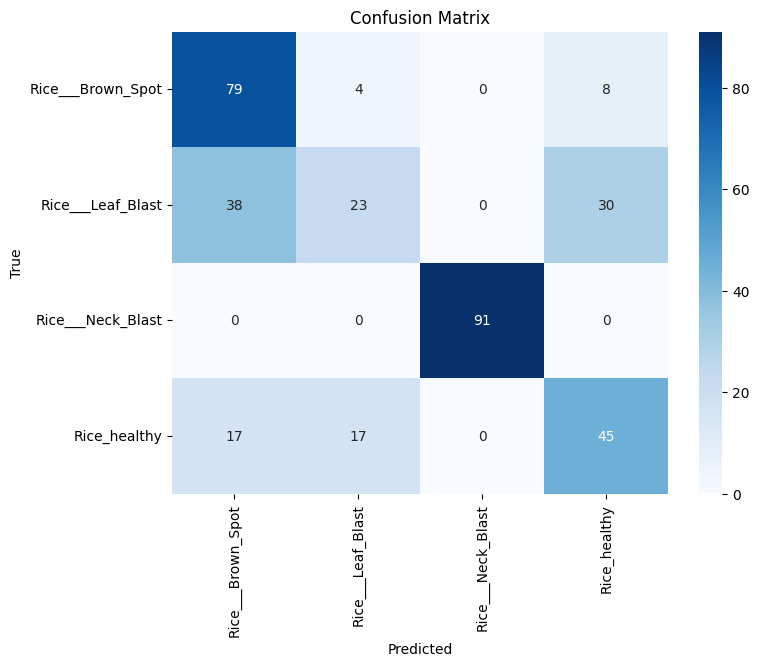

In [ ]:
# بارگذاری داده‌های تست
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/My Drive/plant-disease-detection/Processed Data/Rice/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # مهم: ترتیب داده‌ها تغییر نکند
)

# پیش‌بینی نتایج برای داده‌های تست
y_pred = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size)
y_pred_classes = np.argmax(y_pred, axis=1)  # تبدیل خروجی به کلاس‌های پیش‌بینی شده

# برچسب‌های واقعی
y_true = test_generator.classes

# حذف پیش‌بینی‌های اضافی و برچسب‌های واقعی اضافی
y_true = y_true[:len(y_pred_classes)]
y_pred_classes = y_pred_classes[:len(y_true)]

# ایجاد ماتریس سردرگمی
cm = confusion_matrix(y_true, y_pred_classes)

# رسم ماتریس سردرگمی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

برای گیاه wheat

preprocess

In [ ]:
# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Wheat"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Processing plant: Wheat
  Wheat___Brown_Rust: Train=632, Validation=135, Test=135
  Wheat___Yellow_Rust: Train=648, Validation=138, Test=138
  Wheat_healthy: Train=640, Validation=136, Test=136


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Corn را مشخص کنید
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Wheat"

# پیمایش فولدرهای Train، Validation و Test و شمارش تصاویر
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  Wheat___Brown_Rust: 895 images
  Wheat___Yellow_Rust: 917 images
  Wheat_healthy: 904 images

Validation folder contents:
  Wheat___Brown_Rust: 438 images
  Wheat___Yellow_Rust: 448 images
  Wheat_healthy: 420 images

Test folder contents:
  Wheat___Brown_Rust: 428 images
  Wheat___Yellow_Rust: 442 images
  Wheat_healthy: 419 images


In [ ]:
import os
import shutil

# تابع برای حذف فولدرها و داده‌های داخل آنها
def remove_folders(base_path):
    for folder in ['Train', 'Validation', 'Test']:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)  # حذف فولدر و محتوای داخل آن
            print(f"Deleted {folder} folder.")

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Tomato
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Wheat"

# حذف فولدرهای قبلی
remove_folders(base_path)

# اکنون می‌توانید کد تقسیم داده‌ها را دوباره اجرا کنید:
# نسبت‌های تقسیم‌بندی
test_ratio = 0.15
val_ratio = 0.15

# تابع تقسیم داده‌ها
def split_data_for_plant(plant_path, output_base_path):
    if not os.path.exists(plant_path):
        print("Invalid plant path. Please check the folder path.")
        return

    plant_name = os.path.basename(plant_path)
    output_path = os.path.join(output_base_path, plant_name)
    train_path = os.path.join(output_path, "Train")
    val_path = os.path.join(output_path, "Validation")
    test_path = os.path.join(output_path, "Test")

    for folder in [train_path, val_path, test_path]:
        os.makedirs(folder, exist_ok=True)

    print(f"Processing plant: {plant_name}")
    for disease in sorted(os.listdir(plant_path)):
        disease_path = os.path.join(plant_path, disease)
        if os.path.isdir(disease_path):
            files = [f for f in os.listdir(disease_path)
                     if os.path.isfile(os.path.join(disease_path, f)) and f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            random.shuffle(files)
            total_files = len(files)

            test_count = int(total_files * test_ratio)
            val_count = int(total_files * val_ratio)

            test_files = files[:test_count]
            val_files = files[test_count:test_count + val_count]
            train_files = files[test_count + val_count:]

            for file_set, target_path in zip([train_files, val_files, test_files], [train_path, val_path, test_path]):
                disease_output_path = os.path.join(target_path, disease)
                os.makedirs(disease_output_path, exist_ok=True)
                for file in file_set:
                    shutil.copy(os.path.join(disease_path, file), os.path.join(disease_output_path, file))

            print(f"  {disease}: Train={len(train_files)}, Validation={len(val_files)}, Test={len(test_files)}")

# مسیر گیاه و فولدر خروجی
corn_path = "/content/drive/My Drive/plant-disease-detection/Plant Disease Detection/Wheat"
output_base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data"

# اجرا
split_data_for_plant(corn_path, output_base_path)

Deleted Train folder.
Deleted Validation folder.
Deleted Test folder.
Processing plant: Wheat
  Wheat___Brown_Rust: Train=632, Validation=135, Test=135
  Wheat___Yellow_Rust: Train=648, Validation=138, Test=138
  Wheat_healthy: Train=640, Validation=136, Test=136


In [ ]:
import os

# مسیر فولدر دیتاست تقسیم‌بندی شده برای گیاه Tomato
base_path = "/content/drive/My Drive/plant-disease-detection/Processed Data/Wheat"

# تابع برای شمارش تصاویر در هر دسته
def check_data_structure(base_path):
    if not os.path.exists(base_path):
        print("Invalid base path. Please check the folder path.")
        return

    for folder in ['Train', 'Validation', 'Test']:
        print(f"\n{folder} folder contents:")
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path):
            for disease in sorted(os.listdir(folder_path)):
                disease_path = os.path.join(folder_path, disease)
                if os.path.isdir(disease_path):
                    image_count = len([file for file in os.listdir(disease_path) if os.path.isfile(os.path.join(disease_path, file)) and file.lower().endswith(('.jpg', '.png', '.jpeg'))])
                    print(f"  {disease}: {image_count} images")

# اجرا
check_data_structure(base_path)


Train folder contents:
  Wheat___Brown_Rust: 632 images
  Wheat___Yellow_Rust: 648 images
  Wheat_healthy: 640 images

Validation folder contents:
  Wheat___Brown_Rust: 135 images
  Wheat___Yellow_Rust: 138 images
  Wheat_healthy: 136 images

Test folder contents:
  Wheat___Brown_Rust: 135 images
  Wheat___Yellow_Rust: 138 images
  Wheat_healthy: 136 images


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# مسیر فولدرهای داده‌ها
train_dir = "/content/drive/My Drive/plant-disease-detection/Processed Data/Wheat/Train"
val_dir = "/content/drive/My Drive/plant-disease-detection/Processed Data/Wheat/Validation"
test_dir = "/content/drive/My Drive/plant-disease-detection/Processed Data/Wheat/Test"

In [ ]:
# ایجاد ImageDataGenerators برای داده‌های آموزشی، اعتبارسنجی و تست
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, width_shift_range=0.2,
                                   height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
                                   horizontal_flip=True, fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 1920 images belonging to 3 classes.
Found 409 images belonging to 3 classes.
Found 409 images belonging to 3 classes.


In [ ]:
# بارگذاری مدل MobileNetV2 از پیش آموزش‌دیده
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# لایه‌های جدید مدل
model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())  # کاهش ابعاد ویژگی‌ها
model.add(layers.Dense(512, activation='relu'))  # لایه Fully Connected
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))  # تعداد دسته‌ها مطابق با بیماری‌ها

In [ ]:
# تنظیمات مدل
base_model.trainable = False  # جلوگیری از آموزش لایه‌های پیش‌آموزش دیده

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# آموزش مدل
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


60/60 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.7474 - loss: 0.7847 - val_accuracy: 0.9511 - val_loss: 0.1396
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.9629 - loss: 0.1063 - val_accuracy: 0.9315 - val_loss: 0.1648
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9794 - loss: 0.0771 - val_accuracy: 0.9462 - val_loss: 0.1298
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9753 - loss: 0.0596 - val_accuracy: 0.9413 - val_loss: 0.1530
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9823 - loss: 0.0539 - val_accuracy: 0.9633 - val_loss: 0.1234
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9622 - loss: 0.1127 - val_accuracy: 0.9071 - val_loss: 0.2482
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9824 - loss: 0.0591 - val_accuracy: 0.9560 - val_loss: 0.1312
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9800 - loss: 0.0553 - val_accuracy: 0.9535 - val_loss: 0.

In [ ]:
# ارزیابی مدل روی داده‌های تست
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9550 - loss: 0.1220
Test accuracy: 96.58%


In [ ]:
# ذخیره مدل به صورت HDF5
model.save("/content/drive/My Drive/plant-disease-detection/models/Wheat_plant_disease_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

# مشخص کردن فولدر برای جستجو
model_folder = "/content/drive/My Drive/plant-disease-detection/models"

# لیست کردن فایل‌های داخل پوشه
model_files = [f for f in os.listdir(model_folder) if f.endswith('.h5')]

# نمایش فایل‌ها
print("Model files found:")
for file in model_files:
    print(f"- {file}")

Model files found:
- corn_plant_disease_model.h5
- Tomato_plant_disease_model.h5
- Rice_plant_disease_model.h5
- Wheat_plant_disease_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


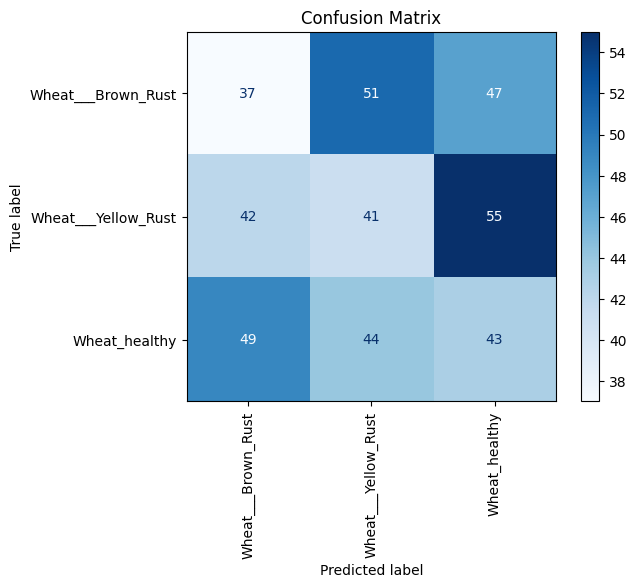

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)


y_true = test_generator.classes

# بررسی ابعاد y_true و y_pred_classes
if len(y_true) != len(y_pred_classes):
    print("Mismatch in y_true and y_pred_classes lengths!")
else:
    # ایجاد ماتریس سردرگمی
    cm = confusion_matrix(y_true, y_pred_classes)
    class_names = list(test_generator.class_indices.keys())  # نام کلاس‌ها

    # رسم ماتریس سردرگمی
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
    plt.title("Confusion Matrix")
    plt.show()

فراخوانی

لطفاً یکی از گیاه‌های زیر را انتخاب کنید: Corn, Tomato, Rice, Wheat


Model for Corn loaded successfully!
لطفاً یک تصویر آپلود کنید:


Saving corn-grey-leaf-spot.jpg to corn-grey-leaf-spot.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Disease: grey_leaf_spot (1.00% confidence)
Solution: کاهش رطوبت برگ‌ها با آبیاری مناسب و جلوگیری از آبیاری بارانی، استفاده از قارچ‌کش‌هایی مانند مانکوزب، فلوکونازول یا کلروتالونیل


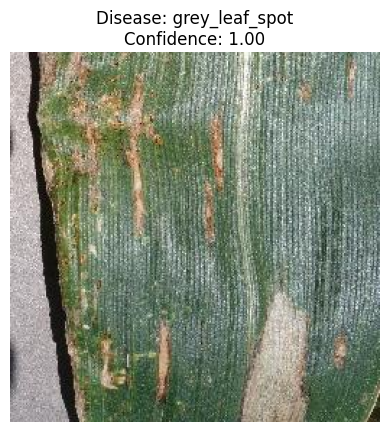

In [ ]:
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# تعریف مدل‌ها، دسته‌ها و راه‌حل‌ها برای هر گیاه
models = {
    "Corn": {
    "model_path": "/content/drive/My Drive/plant-disease-detection/models/corn_plant_disease_model.h5",
    "class_names": ['common_rust', 'grey_leaf_spot', 'healthy', 'northern_leaf_blight'],
    "solutions": {
        'healthy': "گیاه شما سالم می‌باشد.",
        'grey_leaf_spot': "کاهش رطوبت برگ‌ها با آبیاری مناسب و جلوگیری از آبیاری بارانی، استفاده از قارچ‌کش‌هایی مانند مانکوزب، فلوکونازول یا کلروتالونیل",
        'common_rust': "آبیاری قطره‌ای برای کاهش رطوبت روی برگ‌ها، استفاده از قارچ‌کش‌های تماسی مانند پروپیکونازول یا فلوکونازول",
        'northern_leaf_blight': "استفاده از قارچ‌کش‌های سیستمیک مانند متالاکسیل یا فوزاریوم، حذف برگ‌های آلوده و جلوگیری از رشد آن‌ها"
      }
    },
    "Tomato": {
        "model_path": "/content/drive/My Drive/plant-disease-detection/models/Tomato_plant_disease_model.h5",
        "class_names": [
            'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
            'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite',
            'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus',
            'Tomato_healthy'
        ],
        "solutions": {
            'Tomato_Healthy': "گیاه شما سالم می‌باشد.",
            'Tomato__Target_Spot': "تناوب زراعی، آبیاری قطره‌ای، قارچ‌کش‌هایی مانند کلروتالونیل.",
            'Tomato__Tomato_YellowLeaf__Curl_Virus': "کنترل مگس سفید با حشره‌کش‌ها و پوشاندن بوته‌ها.",
            'Tomato_Bacterial_spot': "جلوگیری از آبیاری بارانی، ترکیبات مسی.",
            'Tomato_Early_blight': "تهویه مناسب، قارچ‌کش‌هایی مانند مانکوزب.",
            'Tomato_Late_blight': "ضدعفونی بذرها، حذف بقایای گیاهی، قارچ‌کش‌های سیستمیک.",
            'Tomato_Leaf_Mold': "تهویه مناسب، قارچ‌کش‌هایی مانند کلروتالونیل.",
            'Tomato_Septoria_leaf_spot': "حذف برگ‌های آلوده، استفاده از مانکوزب.",
            'Tomato_Spider_mites_Two_spotted_spider_mite': "استفاده از کفشدوزک‌ها و آفت‌کش‌های طبیعی."
        }
    },
    "Rice": {
        "model_path": "/content/drive/My Drive/plant-disease-detection/models/Rice_plant_disease_model.h5",
        "class_names": ['Rice___Brown_Spot', 'Rice___Leaf_Blast', 'Rice___Neck_Blast', 'Rice_healthy'],
        "solutions": {
            'Rice_healthy': "گیاه شما سالم می‌باشد.",
            'Rice___Brown_Spot': "رعایت فاصله کاشت مناسب و جلوگیری از تراکم بیش از حد گیاهان، تنظیم آبیاری به‌گونه‌ای که رطوبت اضافی روی برگ‌ها جمع نشود، استفاده از قارچ‌کش‌هایی مانند مانکوزب، پِریدابن یا فوزاریوم",
            'Rice___Leaf_Blast': "استفاده از تناوب زراعی برای کاهش بقای پاتوژن‌ها در خاک، جلوگیری از آبیاری بیش از حد و اطمینان از تهویه خوب در مزرع، استفاده از قارچ‌کش‌های سیستمیک مانند متالاکسیل یا فوزاریوم",
            'Rice___Neck_Blast': "رعایت فاصله کاشت برای بهبود گردش هوا و کاهش رطوبت، استفاده از قارچ‌کش‌های سیستمیک مانند متالاکسیل یا تریفلوزول"
        }
    },
    "Wheat": {
    "model_path": "/content/drive/My Drive/plant-disease-detection/models/Wheat_plant_disease_model.h5",
    "class_names": [
        'Wheat___Brown_Rust', 'Wheat___Yellow_Rust', 'Wheat_healthy'
    ],
    "solutions": {
        'Wheat_healthy': "گیاه شما سالم می‌باشد.",
        'Wheat___Brown_Rust': "تناوب زراعی با گیاهانی که میزبان بیماری نیستند (مثلاً با استفاده از حبوبات)، استفاده از قارچ‌کش‌های تماسی مانند پروپیکونازول یا فلوکونازول، در صورت شیوع گسترده، استفاده از ترکیب قارچ‌کش‌ها به‌صورت متناوب برای کاهش مقاومت پاتوژن‌ها",
        'Wheat___Yellow_Rust': "انتخاب مکان‌های کشت مناسب با تهویه خوب برای جلوگیری از رطوبت بالا، انتخاب زمان مناسب کاشت برای جلوگیری از شیوع زودهنگام بیماری، استفاده از قارچ‌کش‌های سیستمیک و تماسی مانند تریفلوسول و پروپیکونازول"
      }
    },
}

# تابع پیش‌بینی تصویر
def predict_image(model, class_names, image_path):
    # بارگذاری و پیش‌پردازش تصویر
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # پیش‌بینی
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    confidence = prediction[0][predicted_class_index]

    return class_names[predicted_class_index], confidence

# انتخاب گیاه
print("لطفاً یکی از گیاه‌های زیر را انتخاب کنید: Corn, Tomato, Rice, Wheat")
plant_choice = input("انتخاب گیاه: ").strip()

# بررسی انتخاب و بارگذاری مدل مرتبط
if plant_choice in models:
    plant_info = models[plant_choice]
    model = load_model(plant_info["model_path"])
    print(f"Model for {plant_choice} loaded successfully!")

    # آپلود فایل تصویر
    print("لطفاً یک تصویر آپلود کنید:")
    uploaded = files.upload()

    # پیش‌بینی و نمایش نتایج
    for filename in uploaded.keys():
        predicted_class, confidence = predict_image(model, plant_info["class_names"], filename)
        solution = plant_info["solutions"].get(predicted_class, "راه‌حلی تعریف نشده است.")

        print(f"Predicted Disease: {predicted_class} ({confidence:.2f}% confidence)")
        print(f"Solution: {solution}")

        # نمایش تصویر
        img = load_img(filename)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Disease: {predicted_class}\nConfidence: {confidence:.2f}")
        plt.show()

else:
    print("انتخاب نامعتبر! لطفاً دوباره تلاش کنید.")